In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
#reading the data As r is givven or// should be used for reading as \ is an escape character
#reading session
bookingDf=pd.read_csv(r'E:\DOCS\Eduraka\Bookings.csv')
sessionDf=pd.read_csv(r"E:\DOCS\Eduraka\Sessions.csv")

In [25]:
#finding the total no of Distinct elements as to find real data (non duplicates) mainly Bookings, Sessions, and Searches.
DistinctBooking=bookingDf['booking_id'].nunique()
DistinctSession=sessionDf['session_id'].nunique()
DistinctSearch=sessionDf['search_id'].nunique()
print("Distinct Booking ID:",DistinctBooking)
print("Distinct Sessions:",DistinctSession)
print("Distinct search ID:",DistinctSearch)

Distinct Booking ID: 339
Distinct Sessions: 331
Distinct search ID: 1360


In [11]:
#count sessons with more than one BookingNo
sessionBookingCount=sessionDf.groupby('session_id')['booking_id'].nunique()
#sessions with more than one booking
SessionMoreThanOneBooking=sessionBookingCount[sessionBookingCount>1]
#cont of Session more than 1
countOfSessionMoreThanOneBooking=len(SessionMoreThanOneBooking)

In [40]:
print (sessionBookingCount)
print("mre than one booking in session:",SessionMoreThanOneBooking)
print('count Of Session More Than One Booking: ',countOfSessionMoreThanOneBooking)

session_id
session_0      1
session_1      1
session_10     1
session_100    1
session_101    1
              ..
session_95     1
session_96     1
session_97     1
session_98     1
session_99     1
Name: booking_id, Length: 331, dtype: int64
mre than one booking in session: session_id
session_134    2
session_154    2
session_196    2
session_231    2
session_27     2
session_290    2
session_298    2
session_324    2
session_50     2
session_76     2
Name: booking_id, dtype: int64
count Of Session More Than One Booking:  10


In [51]:
bookingDf.head(5)

,customer_id,booking_id,from_city,from_country,to_city,to_country,booking_time,device_type_used,INR_Amount,service_name,no_of_passengers,days_to_departure,distance_km,day
0,customer_259,booking_82,Gurgaon,India,Ahmedabad,India,2020-02-05 16:12:08+00:00,Desktop,2565.28,MMT,1.0,10.0,747.8,Wednesday
1,customer_303,booking_156,Delhi,India,Brussels,Belgium,2018-11-21 08:21:47+00:00,Android,23120.00,YATRA,1.0,1.0,6701.5,Wednesday
2,customer_203,booking_99,Devanhalli,India,Frankfurt am Main,Germany,2019-12-16 22:54:58+00:00,Android,25717.60,YATRA,1.0,32.0,7712.0,Monday
3,customer_211,booking_319,Gurgaon,India,Frankfurt am Main,Germany,2021-10-29 12:25:38+00:00,Desktop,135969.60,GOIBIBO,2.0,69.0,6112.5,Friday
4,customer_287,booking_222,Gurgaon,India,Roissy-en-France,France,2020-08-11 16:09:10+00:00,Android,31791.20,GOIBIBO,1.0,3.0,6570.4,Tuesday


In [41]:
#converting pre existing date and time to pandas datetime format for:
# Ensuring Correct Data Type:
# If booking_time is stored as a string (object type), operations like sorting, filtering, and time-based
# calculations won’t work properly.
# Converting it to datetime makes it easier to manipulate and analyze time-based data.
# Enables Time-Based Operations:
# Extract year, month, day, hour, etc.
bookingDf['booking_time']=pd.to_datetime(bookingDf['booking_time'])

In [45]:
# creating a new field for days for analysing each day booking
bookingDf["day"]=bookingDf['booking_time'].dt.day_name()
bookingDf.head(5)

,customer_id,booking_id,from_city,from_country,to_city,to_country,booking_time,device_type_used,INR_Amount,service_name,no_of_passengers,days_to_departure,distance_km,day
0,customer_259,booking_82,Gurgaon,India,Ahmedabad,India,2020-02-05 16:12:08+00:00,Desktop,2565.28,MMT,1.0,10.0,747.8,Wednesday
1,customer_303,booking_156,Delhi,India,Brussels,Belgium,2018-11-21 08:21:47+00:00,Android,23120.00,YATRA,1.0,1.0,6701.5,Wednesday
2,customer_203,booking_99,Devanhalli,India,Frankfurt am Main,Germany,2019-12-16 22:54:58+00:00,Android,25717.60,YATRA,1.0,32.0,7712.0,Monday
3,customer_211,booking_319,Gurgaon,India,Frankfurt am Main,Germany,2021-10-29 12:25:38+00:00,Desktop,135969.60,GOIBIBO,2.0,69.0,6112.5,Friday
4,customer_287,booking_222,Gurgaon,India,Roissy-en-France,France,2020-08-11 16:09:10+00:00,Android,31791.20,GOIBIBO,1.0,3.0,6570.4,Tuesday


In [60]:
# creating a df for saving no of boooking at each day in weak to analyze each days booking rate
bookingAtDay=bookingDf['day'].value_counts()
bookingAtDay.head(7)
# # ploting these days bokking in graph for visualization
# plt.figure(figsize=(6, 4))
# plt.bar(bookingAtDay.index, bookingAtDay.values, color='skyblue')

# # Labels and Title
# plt.xlabel('Day of the Week')
# plt.ylabel('Number of Bookings')
# plt.title('Bookings by Day of the Week')

# # Show Plot
# plt.show()

day
Thursday     65
Tuesday      59
Monday       51
Friday       51
Saturday     44
Sunday       35
Wednesday    34
Name: count, dtype: int64

In [64]:
# bookingAtDay is in series as the above code can be used for series virtulization
# we here covert series to dictonary
bookingAtDay_Dict=bookingAtDay.to_dict()
print(bookingAtDay_Dict)

{'Thursday': 65, 'Tuesday': 59, 'Monday': 51, 'Friday': 51, 'Saturday': 44, 'Sunday': 35, 'Wednesday': 34}


The highest booking is recorded in: Thursdays 65


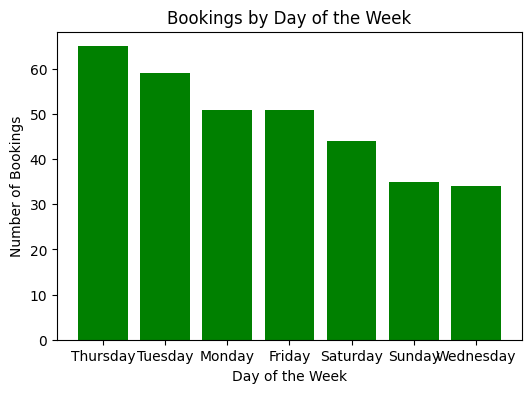

In [88]:
plt.figure(figsize=(6, 4))
plt.bar(bookingAtDay_Dict.keys(),bookingAtDay_Dict.values(),color='green')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Bookings')
plt.title('Bookings by Day of the Week')
mostBookingDate=max(bookingAtDay_Dict,key=bookingAtDay_Dict.get)
mostBookingValue=bookingAtDay_Dict[mostBookingDate]
print("The highest booking is recorded in:",mostBookingDate+"s",mostBookingValue )

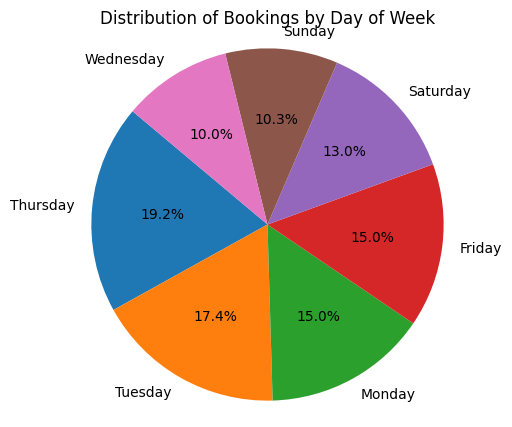

In [91]:
#series data are used
# Plot pie chart
plt.figure(figsize=(5,5))
plt.pie(bookingAtDay, labels=bookingAtDay.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Bookings by Day of Week')
plt.axis('equal')
plt.show()

In [104]:
# total no.fo services available and their total transaction service providerby
booking_service=bookingDf.groupby("service_name").agg({
    "booking_id":"count",
    "INR_Amount":"sum"
}).reset_index()

In [101]:
print(booking_service)

  service_name  booking_id  INR_Amount
0      GOIBIBO         186  5897637.97
1          MMT          48   665669.08
2        YATRA         105  3378702.13


In [114]:
# creating count of customers booking counts
customerBooking=bookingDf["customer_id"].value_counts()
customerBooking.head(5)
customerBookingMore=customerBooking[customerBooking>1]
customerBookingMore.head(5)

customer_id
customer_97     4
customer_246    3
customer_160    3
customer_176    3
customer_230    3
Name: count, dtype: int64

In [141]:
# Find customers with more than 1 booking
customer_booking_counts = bookingDf['customer_id'].value_counts()

# Get only customer IDs where booking count > 1
customers_with_multiple_bookings = customer_booking_counts[customer_booking_counts > 1].index
# Counts how many times each customer booked.
# Filters only those with more than 1 booking.

# Filter dataset for these customers
filtered_bookings = bookingDf[bookingDf['customer_id'].isin(customers_with_multiple_bookings)]
# Ensures only those who booked more than once are considered.
# print(filtered_bookings) 

# Group by (from_city, to_city) and count occurrences
route_counts = filtered_bookings.groupby(['from_city', 'to_city']).size()
# Groups by (from_city, to_city), counts bookings.
# .idxmax() gives the most booked route.


# Find the most booked route
most_booked_route = route_counts.idxmax()

print('Most Booked Route for Customers with More than 1 Booking:')
print(most_booked_route)



Most Booked Route for Customers with More than 1 Booking:
('Gurgaon', 'Roissy-en-France')


In [27]:
# : Top 3 Departure Cities for Advanced Bookings
# To get the top 3 departure cities for bookings made well in advance, we need to:
# Define "advanced booking" → Usually, bookings made many days before departure.
# Find departure cities with the most such bookings.
# Sort them and pick the top 3.

# We assume "advanced booking" means booking at least 7 days before departure:
advanced_bookings= bookingDf[bookingDf['days_to_departure'] >= 7]
advanced_bookings.head(5)
# Count how many bookings each departure city has
advanced_booking_city=advanced_bookings['from_city'].value_counts()
advanced_booking_city.head(5)
top_3_departure_cities = advanced_booking_city.head(3)
print("Top three departure cities:",top_3_departure_cities)
# note: value_counts() already sorts the values in descending order by default.
# So, .head(3) directly picks the top 3 cities with the highest booking counts.

Top three departure cities: from_city
Gurgaon    84
Mumbai     19
Delhi      17
Name: count, dtype: int64


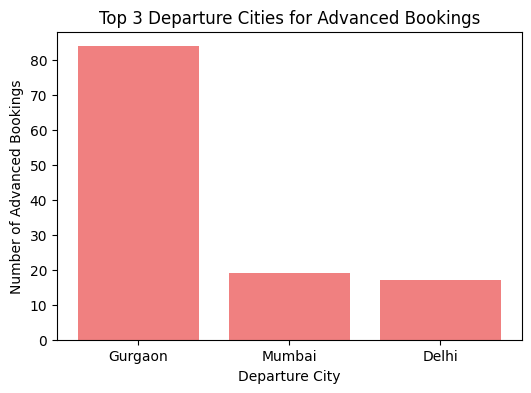

In [28]:
import matplotlib.pyplot as plt

# Plot bar chart
plt.figure(figsize=(6,4))
plt.bar(top_3_departure_cities.index, top_3_departure_cities.values, color='lightcoral')

# Labels and title
plt.xlabel("Departure City")
plt.ylabel("Number of Advanced Bookings")
plt.title("Top 3 Departure Cities for Advanced Bookings")

plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

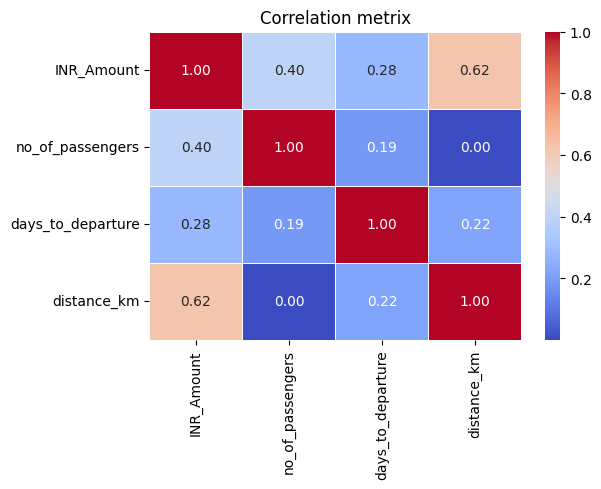

In [37]:
# Heatmap of Correlations in Bookings Dataset:
# A correlation heatmap helps us see relationships between numerical columns in the dataset.
# It shows how strongly different columns are related to each other.

# Exclude non-numeric columns from correlation calculation
numeric_bookingDf=bookingDf.select_dtypes(include=[np.number])
numeric_bookingDf.head(5)

# 1️ Find correlations : .corr() computes the correlation matrix for all numerical columns.
# 2️ Use sns.heatmap() : This visualizes correlations in a color-coded way.
# 3️ Customize colors (cmap="coolwarm") : Red = strong negative correlation, Blue = strong positive correlation.
# 4️ Add annotations (annot=True) : Shows exact correlation values inside each box

correlation_metrix=numeric_bookingDf.corr()
plt.figure(figsize=[6,4])
sns.heatmap(correlation_metrix,cmap="coolwarm",annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation metrix")
plt.show

# Values range from -1 to +1:
# +1 (Strong positive correlation) → As one value increases, the other also increases.
# -1 (Strong negative correlation) → As one value increases, the other decreases.
# 0 (No correlation) → No relationship between values


In [44]:
# Finding the Most Used Device Type by Service

# Step 1: Group by 'service_name' and 'device_type_used' and count occurrences
# How Grouping Works:
# Pandas groups the rows where service_name and device_type_used are the same.
# It then counts how many times each combination appears.
# size() returns the count for each unique pair.
most_used_device_service=bookingDf.groupby(['service_name','device_type_used']).size()
most_used_device.head(5)

# Step 2: Find the most used device for each service
# Finding the Most Used Device for Each Service
# Now, we want to find the most used device type for each service.
#groupby(level=0).idxmax() By usingbothe we can find all catagories most used,,, 
# if we use idxmax() we find the one most occurence

#most_used_device_per_service = df.groupby('service_name')['count'].idxmax().apply(lambda x: df.loc[x, 'device_type_used'])

most_used_device_by_service = most_used_device_service.groupby(level=0).idxmax()
print("Most Used Device Type by Service:")
print(most_used_device_by_service)



Most Used Device Type by Service:
service_name
GOIBIBO      (GOIBIBO, IOS)
MMT          (MMT, Desktop)
YATRA      (YATRA, Desktop)
dtype: object


device_type_used  Android  Desktop  IOS  MobileWeb  Tablet
month                                                     
2018-09               3.0      6.0  NaN        2.0     1.0
2018-10               1.0     14.0  NaN        2.0     1.0
2018-11               2.0      4.0  2.0        2.0     NaN
2018-12               NaN      4.0  2.0        NaN     NaN
2019-01               NaN      1.0  NaN        NaN     NaN


<Figure size 1000x500 with 0 Axes>

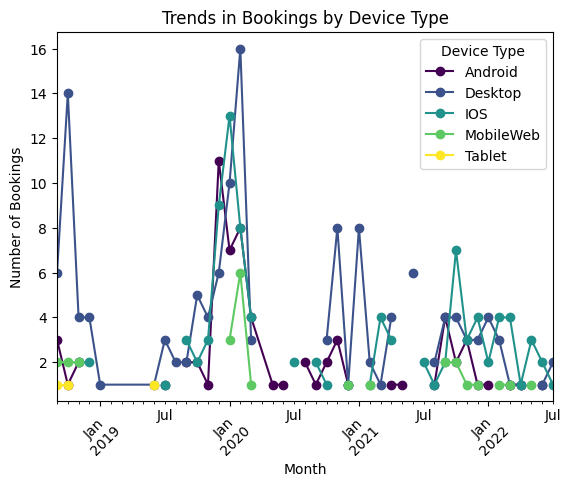

In [59]:
# Trends in Bookings by Device Type:

# Convert Booking Time to Date Format(alredy converted)
bookingDf['booking_time'] = pd.to_datetime(bookingDf['booking_time'])

# bookings_df['booking_time'] = pd.to_datetime(bookings_df['booking_time'])

 # Extract the Month or Week for Trend Analysis

# Step 2: Extract the Month or Week for Trend Analysis
# bookingDf.head(5)
# bookingDf['month']=bookingDf['booking_time'].dt.to_period('M')# Group by month
# The warning "Converting to PeriodArray/Index representation will drop timezone information" means that your booking_time column has a timezone (tz), and when converting to a period ('M' for month), Pandas removes the timezone.

# : Remove the Timezone Before Conversion
# modified
bookingDf['booking_time'] = bookingDf['booking_time'].dt.tz_localize(None) #Remove the Timezone Before Conversion
bookingDf['month'] = bookingDf['booking_time'].dt.to_period('M')
bookingDf.head(5)

device_trend = bookingDf.groupby(['month', 'device_type_used']).size().unstack()
print(device_trend.head()) 

plt.figure(figsize=(10, 5))
device_trend.plot(kind='line', marker='o', colormap='viridis')

# Labels and Title
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.title('Trends in Bookings by Device Type')
plt.legend(title='Device Type')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

plt.show()


In [74]:
# Convert booking_time and search_time to datetime format,

sessionDf['search_time']=pd.to_datetime(sessionDf['search_time'], errors='coerce')
sessionDf.head(5)

# Extract year-month and day of the week
sessionDf['search_time'] = sessionDf['search_time'].dt.tz_localize(None)  # Remove timezone
sessionDf['month'] = sessionDf['search_time'].dt.to_period('M')  # Convert to month period
bookingDf['month'] = bookingDf['booking_time'].dt.to_period('M')


In [76]:
sessionDf.head(5)

,session_id,search_id,search_time,session_starting_time,booking_id,month
0,session_322,search_784,2020-01-21 21:35:38.910,2020-01-21T21:10:12Z,NaN,2020-01
1,session_322,search_776,2020-01-21 21:37:37.697,2020-01-21T21:10:12Z,NaN,2020-01
2,session_322,search_623,2020-01-21 21:36:11.392,2020-01-21T21:10:12Z,NaN,2020-01
3,session_322,search_270,2020-01-21 21:16:07.685,2020-01-21T21:10:12Z,NaN,2020-01
4,session_322,search_905,2020-01-21 21:34:55.673,2020-01-21T21:10:12Z,NaN,2020-01


In [79]:
bookingDf['day_of_week'] = bookingDf['booking_time'].dt.day_name()
sessionDf['day_of_week'] = sessionDf['search_time'].dt.day_name()

bookingDf['date'] = bookingDf['booking_time'].dt.date
sessionDf['date'] = sessionDf['search_time'].dt.date
sessionDf.head(5)


,session_id,search_id,search_time,session_starting_time,booking_id,month,day_of_week,date
0,session_322,search_784,2020-01-21 21:35:38.910,2020-01-21T21:10:12Z,NaN,2020-01,Tuesday,2020-01-21
1,session_322,search_776,2020-01-21 21:37:37.697,2020-01-21T21:10:12Z,NaN,2020-01,Tuesday,2020-01-21
2,session_322,search_623,2020-01-21 21:36:11.392,2020-01-21T21:10:12Z,NaN,2020-01,Tuesday,2020-01-21
3,session_322,search_270,2020-01-21 21:16:07.685,2020-01-21T21:10:12Z,NaN,2020-01,Tuesday,2020-01-21
4,session_322,search_905,2020-01-21 21:34:55.673,2020-01-21T21:10:12Z,NaN,2020-01,Tuesday,2020-01-21


In [80]:
# Calculate bookings and searches per month
monthly_bookings = bookingDf.groupby('month').size()
monthly_searches = sessionDf.groupby('month').size()
monthly_obsr = (monthly_bookings / monthly_searches).reset_index(name='oBSR')
print ("monthly_obsr", monthly_obsr)


monthly_obsr       month      oBSR
0   2018-09  0.363636
1   2018-10  0.087379
2   2018-11  0.217391
3   2018-12  0.171429
4   2019-01  0.200000
5   2019-06  1.000000
6   2019-07  0.208333
7   2019-08  0.285714
8   2019-09  0.280000
9   2019-10  0.214286
10  2019-11  0.258065
11  2019-12  0.213115
12  2020-01  0.200000
13  2020-02  0.283582
14  2020-03  0.255319
15  2020-05       NaN
16  2020-06       NaN
17  2020-07       NaN
18  2020-08       NaN
19  2020-09       NaN
20  2020-10       NaN
21  2020-11       NaN
22  2020-12       NaN
23  2021-01       NaN
24  2021-02       NaN
25  2021-03       NaN
26  2021-04       NaN
27  2021-05       NaN
28  2021-06       NaN
29  2021-07       NaN
30  2021-08       NaN
31  2021-09       NaN
32  2021-10       NaN
33  2021-11       NaN
34  2021-12       NaN
35  2022-01       NaN
36  2022-02       NaN
37  2022-03       NaN
38  2022-04       NaN
39  2022-05       NaN
40  2022-06       NaN
41  2022-07       NaN


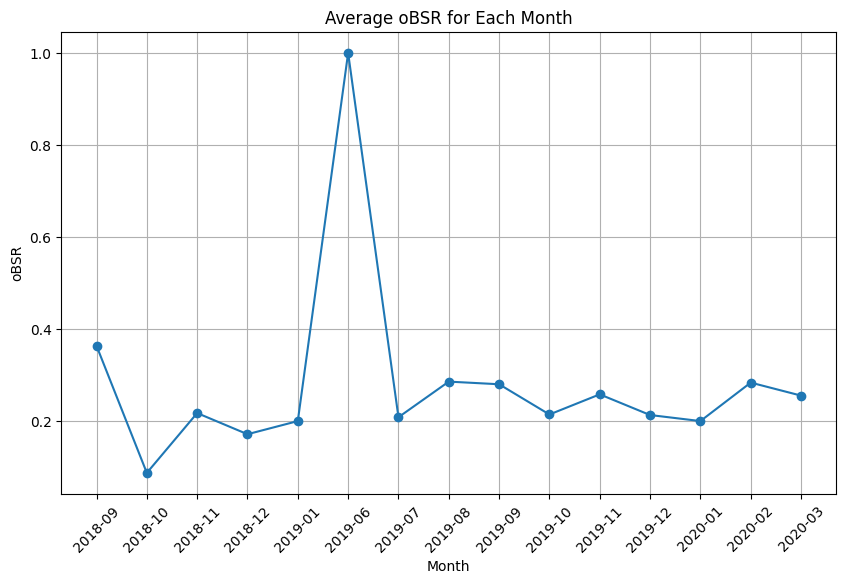

In [81]:
# Plot monthly oBSR
plt.figure(figsize=(10, 6))
plt.plot(monthly_obsr['month'].astype(str), monthly_obsr['oBSR'], marker='o')
plt.title('Average oBSR for Each Month')
plt.xlabel('Month')
plt.ylabel('oBSR')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()